# РГР 3

- Авторы работы:
  - Сакулин Иван Михайлович, 467335, K3221
  - Мурашов Никита Александрович, 466794, K3241
- Предмет: Математическая статистика
- Поток: МатСтат28.3
- Выборка: А-9 из [генератора](https://imath-materials.github.io/mathstat/RGR3_generator_students.html?group=A&variant=9)

# Карточка варианта
- Вариант `A-9`
- Число наблюдений $n = 60$
- Переменные
  - $x$ - Число потоков
  - $y$ - TDP, Вт
- Сравниваемые модели: линейная, квадратичная, степенная.

### Что нужно сделать.
1) построить диаграмму рассеяния и сформулировать гипотезу о характере связи;
2) построить линейную и квадратичную модели;
3) построить дополнительную модель вида $y = a x^b$;
4) сравнить модели по $R²$, RMSE, средней ошибке аппроксимации и графикам;
5) для линейной модели найти остатки, RSS, оценку дисперсии ошибки и доверительные интервалы для коэффициентов;
6) выполнить прогноз при $x^*$, равном $106\%$ от среднего уровня фактора.

Для текущего варианта: $x^* = 22,2600$.

### Краткий прикладной контекст
Теплопакет процессора в зависимости от числа потоков (Intel).

### Источник и срез
- Набор данных: openintro::cpu - CPU's Released between 2010 and 2020.
- [Страница-источник](https://vincentarelbundock.github.io/Rdatasets/doc/openintro/cpu.html)
- Как получен срез: набор openintro::cpu; фильтр company == "Intel".
- Фактор x: число потоков (threads)
- Отклик y: TDP, Вт (tdp)

# Задание

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy

### 1. Первичный анализ данных

In [3]:
df = pd.read_csv("https://drive.usercontent.google.com/u/0/uc?id=1D-1a8_i097wpWwWMYSxP-TchoOF3T-qJ&export=download", sep=',')
X = df['x'].dropna().to_numpy()
Y = df['y'].dropna().to_numpy()

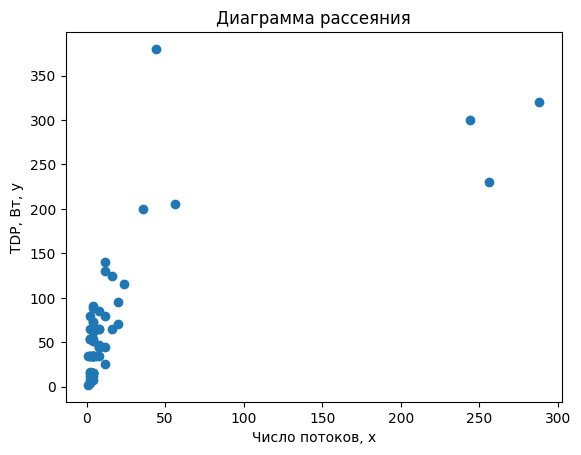

In [4]:
plt.scatter(X, Y)
plt.xlabel('Число потоков, x')
plt.ylabel('TDP, Вт, y')
plt.title('Диаграмма рассеяния')
plt.show()

**Гипотеза о форме и направлении.**

По диаграмме рассеяния наблюдается положительная связь: с ростом числа потоков TDP в среднем увеличивается.

Зависимость выглядит не строго линейной. В области малых значений $x$ точки расположены почти вертикально, то есть при близком числе потоков значения TDP сильно различаются, с другой стороны есть несколько точек с большими значениями $x$ и $y$, что тоже указывает на нелинейность связи.

"Прикинув на глаз" можно представить степенную модель.

### 2. Построение трёх регрессионных моделей

#### Линейная модель

$y = a + bx$

$\bar x = \frac{1}{n}\sum_{i=1}^{n} x_i$

$\bar y = \frac{1}{n}\sum_{i=1}^{n} y_i$

$S_{xx} = \sum_{i=1}^{n}(x_i - \bar x)^2$

$S_{xy} = \sum_{i=1}^{n}(x_i - \bar x)(y_i - \bar y)$

$\hat b = \frac{S_{xy}}{S_{xx}}$

$\hat a = \bar y - \hat b \bar x$

$\hat y_i = \hat a + \hat b x_i$

In [5]:
x_bar = X.mean()
y_bar = Y.mean()

Sxx = ((X - x_bar) ** 2).sum()
Sxy = ((X - x_bar) * (Y - y_bar)).sum()

b_lin = Sxy / Sxx
a_lin = y_bar - b_lin * x_bar

y_hat_lin = a_lin + b_lin * X

print(f"Линейная модель: y = {a_lin:.6f} {'+' if b_lin >= 0 else '-'} {abs(b_lin):.6f}x")

Линейная модель: y = 52.002116 + 0.993550x


#### Квадратичная модель

$y = a + bx + cx^2$

$\hat y_i = \hat a + \hat b x_i + \hat c x_i^2$

In [6]:
c_quad, b_quad, a_quad = np.polyfit(X, Y, 2)
y_hat_quad = a_quad + b_quad * X + c_quad * X**2

print(f"Квадратичная модель: y = {a_quad:.6f} {'+' if b_quad >= 0 else '-'} {abs(b_quad):.6f}x {'+' if c_quad >= 0 else '-'} {abs(c_quad):.6f}x²")

Квадратичная модель: y = 25.085872 + 4.652367x - 0.013743x²


#### Степенная модель

$y = ax^b$

$\ln y = \ln a + b \ln x$

$u_i = \ln x_i,\quad v_i = \ln y_i$

$v = \ln a + bu$

$\hat a = e^{\widehat{\ln a}}$

$\hat y_i = \hat a x_i^{\hat b}$

In [7]:
b_pow, ln_a_pow = np.polyfit(np.log(X), np.log(Y), 1)
a_pow = np.exp(ln_a_pow)

y_hat_pow = a_pow * X**b_pow

print(f"Степенная модель: y = {a_pow:.4f}x^({b_pow:.4f})")

Степенная модель: y = 15.6714x^(0.5875)


#### Графики моделей

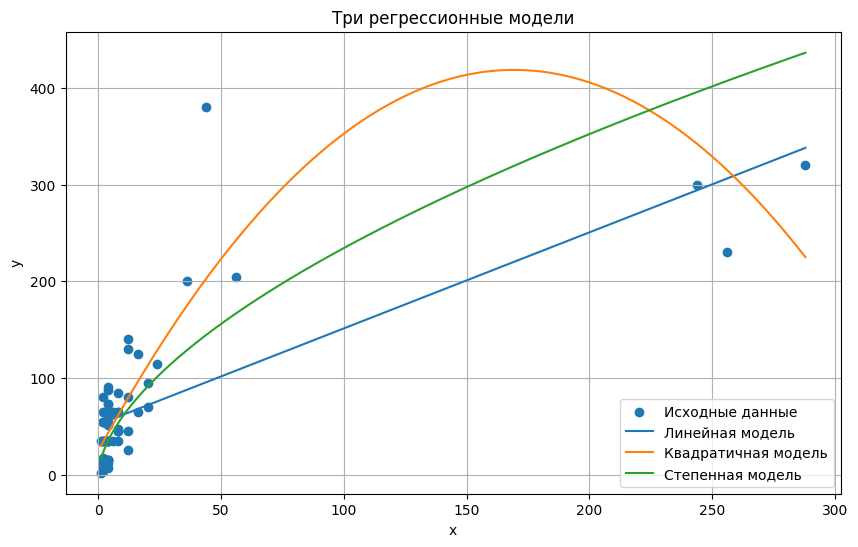

In [8]:
x_grid = np.linspace(X.min(), X.max(), 500)

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label='Исходные данные')
plt.plot(x_grid, a_lin + b_lin * x_grid, label='Линейная модель')
plt.plot(x_grid, a_quad + b_quad * x_grid + c_quad * x_grid**2, label='Квадратичная модель')
plt.plot(x_grid, a_pow * x_grid**b_pow, label='Степенная модель')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Три регрессионные модели')
plt.legend()
plt.grid(True)
plt.show()

#### Прогнозные значения $y^*$

In [9]:
pred_table = pd.DataFrame({
    'x': X,
    'y': Y,
    'ŷ_lin': y_hat_lin,
    'ŷ_quad': y_hat_quad,
    'ŷ_pow': y_hat_pow
}).round(3)

display(pred_table)

,x,y,ŷ_lin,ŷ_quad,ŷ_pow
0,1.0,35.0,52.996,29.724,15.671
1,1.0,2.0,52.996,29.724,15.671
2,2.0,12.0,53.989,34.336,23.549
3,2.0,65.0,53.989,34.336,23.549
4,2.0,54.0,53.989,34.336,23.549
5,2.0,17.0,53.989,34.336,23.549
6,2.0,15.0,53.989,34.336,23.549
7,2.0,35.0,53.989,34.336,23.549
8,2.0,35.0,53.989,34.336,23.549
9,2.0,7.0,53.989,34.336,23.549


### 3. Сравнение моделей

$RSS = \sum_{i=1}^{n}(y_i - \hat y_i)^2$

$TSS = \sum_{i=1}^{n}(y_i - \bar y)^2$

$R^2 = 1 - \frac{RSS}{TSS}$

$A = \frac{100\%}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat y_i}{y_i}\right|$

In [10]:
TSS = ((Y - y_bar) ** 2).sum()

def model_metrics(y_true, y_pred):
    rss = ((y_true - y_pred) ** 2).sum()
    r2 = 1 - rss / TSS
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rss, r2, mape

metrics = pd.DataFrame([
    ['Линейная', *model_metrics(Y, y_hat_lin)],
    ['Квадратичная', *model_metrics(Y, y_hat_quad)],
    ['Степенная', *model_metrics(Y, y_hat_pow)],
], columns=['Модель', 'RSS', 'R²', 'Средняя ошибка аппроксимации, %']).round(3)

display(metrics)

,Модель,RSS,R²,"Средняя ошибка аппроксимации, %"
0,Линейная,159810.968,0.542,152.537
1,Квадратичная,89374.475,0.744,102.514
2,Степенная,156496.658,0.551,75.655


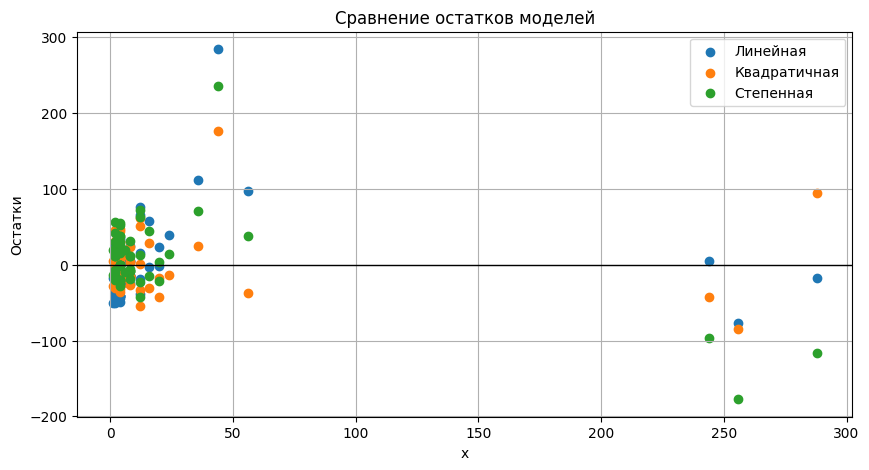

In [11]:
res_lin = Y - y_hat_lin
res_quad = Y - y_hat_quad
res_pow = Y - y_hat_pow

plt.figure(figsize=(10, 5))
plt.scatter(X, res_lin, label='Линейная')
plt.scatter(X, res_quad, label='Квадратичная')
plt.scatter(X, res_pow, label='Степенная')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('x')
plt.ylabel('Остатки')
plt.title('Сравнение остатков моделей')
plt.legend()
plt.grid(True)
plt.show()

Линейная модель хуже по всем трём параметрам. Квадратичная модель имеет меньшие по модулю остатки, больший коэффициент детерминации, однако степенная ближе к реальным данным, но все же сильнее реагирует на выбросы.

Предпочитаем квадратичную модель.

### 4. Подробный статистический анализ линейной модели

1. Оценки коэффициентов $\hat{a}$ и $\hat{b}$
2. прогнозные значения $\hat{y}_i$ и остатки $e_i = y_i - \hat{y}_i$;
3. Остаточная сумма квадратов
4. Несмещённая оценка дисперсии ошибки
5. Доверительные интервалы для коэффициентов линейной регрессии

$\hat y_i = \hat a + \hat b x_i$

$e_i = y_i - \hat y_i$

$RSS = \sum_{i=1}^{n} e_i^2$

$s^2 = \frac{RSS}{n - 2}$

$s = \sqrt{s^2}$

$SE(\hat b) = \frac{s}{\sqrt{S_{xx}}}$

$SE(\hat a) = s\sqrt{\frac{1}{n} + \frac{\bar x^2}{S_{xx}}}$

$\hat a \pm t_{0.975;n-2}\cdot SE(\hat a)$

$\hat b \pm t_{0.975;n-2}\cdot SE(\hat b)$

$H_0: b = 0$

$H_1: b \ne 0$

$t_{\text{набл}} = \frac{\hat b}{SE(\hat b)}$

In [12]:
RSS_lin = ((Y - y_hat_lin) ** 2).sum()
n = len(X)
s2 = RSS_lin / (n - 2)
s = np.sqrt(s2)

SE_b = s / np.sqrt(Sxx)
SE_a = s * np.sqrt(1 / n + x_bar**2 / Sxx)

t_crit = scipy.stats.t.ppf(0.975, df=n - 2)

ci_a = (a_lin - t_crit * SE_a, a_lin + t_crit * SE_a)
ci_b = (b_lin - t_crit * SE_b, b_lin + t_crit * SE_b)

t_obs = b_lin / SE_b
p_value = 2 * (1 - scipy.stats.t.cdf(abs(t_obs), df=n - 2))

In [13]:
linear_stats = pd.DataFrame({
    'Показатель': [
        'â', 'b̂', 'RSS', 's²', 's',
        'SE(â)', 'SE(b̂)',
        '95% ДИ для â', '95% ДИ для b̂',
        'tнабл', 'tкрит', 'p-value'
    ],
    'Значение': [
        round(a_lin, 4), round(b_lin, 4), round(RSS_lin, 4), round(s2, 4), round(s, 4),
        round(SE_a, 4), round(SE_b, 4),
        f'[{ci_a[0]:.4f}; {ci_a[1]:.4f}]',
        f'[{ci_b[0]:.4f}; {ci_b[1]:.4f}]',
        round(t_obs, 4), round(t_crit, 4), f'{p_value:.6g}'
    ]
})

display(linear_stats)

,Показатель,Значение
0,â,52.0021
1,b̂,0.9936
2,RSS,159810.9676
3,s²,2755.3615
4,s,52.4915
5,SE(â),7.2297
6,SE(b̂),0.12
7,95% ДИ для â,[37.5303; 66.4740]
8,95% ДИ для b̂,[0.7534; 1.2337]
9,tнабл,8.2824


2. прогнозные значения $\hat{y}_i$ и остатки $e_i = y_i - \hat{y}_i$;

In [17]:
residuals_table = pd.DataFrame({
    'x': X,
    'y': Y,
    'ŷ (линейная)': y_hat_lin,
    'e = y - ŷ': Y - y_hat_lin
}).round(3)

display(residuals_table)

,x,y,ŷ (линейная),e = y - ŷ
0,1.0,35.0,52.996,-17.996
1,1.0,2.0,52.996,-50.996
2,2.0,12.0,53.989,-41.989
3,2.0,65.0,53.989,11.011
4,2.0,54.0,53.989,0.011
5,2.0,17.0,53.989,-36.989
6,2.0,15.0,53.989,-38.989
7,2.0,35.0,53.989,-18.989
8,2.0,35.0,53.989,-18.989
9,2.0,7.0,53.989,-46.989


6. Гипотеза $H_0: b = 0$ и $H_1: b \ne 0$
7. Статистическая значимость коэффициента при $x$

In [15]:
if abs(t_obs) > t_crit:
    print("Гипотеза H0 отвергается.")
    print("Коэффициент при x статистически значим на уровне α = 0.05.")
else:
    print("Нет оснований отвергать H0.")
    print("Коэффициент при x статистически незначим на уровне α = 0.05.")

Гипотеза H0 отвергается.
Коэффициент при x статистически значим на уровне α = 0.05.


Гипотеза $H_0: b = 0$ отвергается по t-критерию Стьюдента.

Так как $|t_{\text{набл}}| > t_{\text{крит}}$, то коэффициент при $x$ статистически значим.

### 5. Прогноз и интерпретация

$\hat y(x^*) = \hat a + \hat b x^*$

$\hat y(x^*) = \hat a + \hat b x^* + \hat c(x^*)^2$

$\hat y(x^*) = \hat a (x^*)^{\hat b}$

In [16]:
x_star = 22.26
predictions = pd.DataFrame({
    'Модель': ['Линейная', 'Квадратичная', 'Степенная'],
    'Прогноз при x*': [
        a_lin + b_lin * x_star,
        a_quad + b_quad * x_star + c_quad * x_star**2,
        a_pow * x_star**b_pow
    ]
}).round(3)

display(predictions)

,Модель,Прогноз при x*
0,Линейная,74.119
1,Квадратичная,121.838
2,Степенная,97.010


Выше мы с обоснованием выбрали квадратичную модель для оценки, по ней получаем $y^*(22.26) = 121.84$.

**Интерпритируем на реальную выборку**: если процессор Intel имеет около 22 потоков (что около среднего по выборке), то квадратичная модель оценивает его тепловыделение примерно в 122 Вт.

### 6. Итоговый вывод

В конце отчёта общий итог работы (7–12 строк):
1. какой реальный набор данных исследовался;
2. какая зависимость изучалась;
3. какие модели были построены;
4. какая модель оказалась предпочтительной и почему;
5. как интерпретировать найденную зависимость содержательно.

В заключении рекомендуется ответить на вопросы:
1. Какой вид имеет найденная зависимость между $x$ и $y$?
2. Является ли связь положительной или отрицательной?
3. Какая из трёх моделей лучше описывает данные?
4. Насколько линейная модель статистически значима?
5. Как интерпретируется прогноз для заданного значения $x^*$?

Исследовалась зависимость TDP процессоров Intel от числа потоков по данным 2010–2020 гг. Построены линейная, квадратичная и степенная модели. Квадратичная модель \(y = 25,09 + 4,65x - 0,0137x^2\) оказалась предпочтительной: у неё наибольший \(R^2 = 0,744\) и наименьшая RSS = 89 374. Линейная и степенная модели хуже описывают нелинейность данных. Коэффициент линейной модели статистически значим (\(p < 0,001\)), но сама линейная модель проигрывает квадратичной. Для \(x^* = 22,26\) (106% от среднего) прогноз по квадратичной модели — 122 Вт. Связь между числом потоков и TDP положительная, нелинейная, с ускорением.
